# Custom LSTM Anomaly Detection
Training an LSTM autoencoder on custom 'with/without 3 lamps' data and evaluating against the 'test' folder.

In [2]:
%pip install pandas numpy torch scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import glob
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Hyperparameters
SEQ_LENGTH = 40
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


## Data Loading & Preprocessing
We load the CSV files, extract the Voltage (`V_v`) and Current (`I_a`) columns, and split them into 40-step sequences on a per-file basis so we don't bleed data across disjoint runs.

In [4]:
def load_sequences_from_folders(folders, seq_length=SEQ_LENGTH):
    sequences = []
    total_files = 0
    for folder in folders:
        files = glob.glob(os.path.join(folder, '*.csv'))
        for f in files:
            try:
                # Some files have trailing commas, so we just grab the known columns
                df = pd.read_csv(f, on_bad_lines='skip', low_memory=False)
                if 'V_v' in df.columns and 'I_a' in df.columns:
                    v = pd.to_numeric(df['V_v'], errors='coerce').fillna(0).values
                    i = pd.to_numeric(df['I_a'], errors='coerce').fillna(0).values
                    
                    data = np.column_stack((v, i))
                    
                    # Chop into sequences
                    num_seqs = len(data) // seq_length
                    for s in range(num_seqs):
                        sequences.append(data[s*seq_length : (s+1)*seq_length])
                    total_files += 1
            except Exception as e:
                print(f"Error processing {f}: {e}")
                
    print(f"Processed {total_files} files from {folders}")
    return np.array(sequences)

# Load normal data
normal_folders = ['with 3 lamps', 'without 3 lamps']
normal_sequences = load_sequences_from_folders(normal_folders)
print(f"Total Normal Sequences: {normal_sequences.shape}")

# Load test/anomalous data
test_folders = ['test']
test_sequences = load_sequences_from_folders(test_folders)
print(f"Total Test Sequences: {test_sequences.shape}")


Error processing with 3 lamps\device_diningroom1_fridge1.csv: Error tokenizing data. C error: EOF inside string starting at row 944
Processed 55 files from ['with 3 lamps', 'without 3 lamps']
Total Normal Sequences: (2450, 40, 2)
Processed 8 files from ['test']
Total Test Sequences: (200, 40, 2)


In [5]:
# Train-Test Split for Normal Data (80/20)
# We want to train ONLY on normal data so the autoencoder learns the baseline.
train_normal, val_normal = train_test_split(normal_sequences, test_size=0.2, random_state=42)

print(f"Training Normal Sequences: {train_normal.shape}")
print(f"Validation Normal Sequences: {val_normal.shape}")

# Normalize the data using a Scaler fit ONLY on the training data
scaler = StandardScaler()

# Flatten to (N*SEQ_LENGTH, 2) to scale, then reshape back
def scale_sequences(seqs, scaler, fit=False):
    N, L, F = seqs.shape
    flat = seqs.reshape(-1, F)
    if fit:
        scaled_flat = scaler.fit_transform(flat)
    else:
        scaled_flat = scaler.transform(flat)
    return scaled_flat.reshape(N, L, F)

train_normal_scaled = scale_sequences(train_normal, scaler, fit=True)
val_normal_scaled = scale_sequences(val_normal, scaler, fit=False)
test_sequences_scaled = scale_sequences(test_sequences, scaler, fit=False)

# Convert to PyTorch DataLoaders
train_tensor = torch.tensor(train_normal_scaled, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(train_tensor, train_tensor), batch_size=BATCH_SIZE, shuffle=True)

val_tensor = torch.tensor(val_normal_scaled, dtype=torch.float32)
val_loader = DataLoader(TensorDataset(val_tensor, val_tensor), batch_size=BATCH_SIZE, shuffle=False)

test_tensor = torch.tensor(test_sequences_scaled, dtype=torch.float32)
test_loader = DataLoader(TensorDataset(test_tensor, test_tensor), batch_size=BATCH_SIZE, shuffle=False)


Training Normal Sequences: (1960, 40, 2)
Validation Normal Sequences: (490, 40, 2)


## LSTM Autoencoder Model
We use an LSTM autoencoder. The encoder compresses the sequence, and the decoder reconstructs it.

In [6]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, num_layers=2):
        super(LSTMAutoencoder, self).__init__()
        # Encoder
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        # Decoder
        self.decoder = nn.LSTM(hidden_dim, input_dim, num_layers, batch_first=True)
        
    def forward(self, x):
        # x shape: (batch, seq_len, features)
        # Encoder passes output and hidden states
        _, (h, c) = self.encoder(x)
        
        # We need to provide the hidden state to the decoder.
        # But for autoencoders, typically we repeat the last hidden state for seq_length times.
        # h shape: (num_layers, batch, hidden_dim). Take the last layer's hidden state.
        last_h = h[-1].unsqueeze(1) # shape: (batch, 1, hidden_dim)
        decoder_input = last_h.repeat(1, x.size(1), 1) # shape: (batch, seq_len, hidden_dim)
        
        out, _ = self.decoder(decoder_input)
        return out

model = LSTMAutoencoder(input_dim=2).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(model)


LSTMAutoencoder(
  (encoder): LSTM(2, 64, num_layers=2, batch_first=True)
  (decoder): LSTM(64, 2, num_layers=2, batch_first=True)
)


## Training
Training the model to minimize reconstruction error on the normal data.

In [7]:
train_loss_history = []
val_loss_history = []

for epoch in range(EPOCHS):
    model.train()
    epoch_train_loss = 0
    for batch_x, _ in train_loader:
        batch_x = batch_x.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_x)
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item() * batch_x.size(0)
        
    epoch_train_loss /= len(train_loader.dataset)
    train_loss_history.append(epoch_train_loss)
    
    # Validation step
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for batch_x, _ in val_loader:
            batch_x = batch_x.to(DEVICE)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_x)
            epoch_val_loss += loss.item() * batch_x.size(0)
            
    epoch_val_loss /= len(val_loader.dataset)
    val_loss_history.append(epoch_val_loss)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss (MSE): {epoch_train_loss:.6f} | Val Loss (MSE): {epoch_val_loss:.6f}")


Epoch 1/10 | Train Loss (MSE): 1.000102 | Val Loss (MSE): 0.772638
Epoch 2/10 | Train Loss (MSE): 0.999229 | Val Loss (MSE): 0.771499
Epoch 3/10 | Train Loss (MSE): 0.993241 | Val Loss (MSE): 0.759839
Epoch 4/10 | Train Loss (MSE): 0.978826 | Val Loss (MSE): 0.743989
Epoch 5/10 | Train Loss (MSE): 0.960957 | Val Loss (MSE): 0.724308
Epoch 6/10 | Train Loss (MSE): 0.938894 | Val Loss (MSE): 0.700838
Epoch 7/10 | Train Loss (MSE): 0.922863 | Val Loss (MSE): 0.697794
Epoch 8/10 | Train Loss (MSE): 0.907402 | Val Loss (MSE): 0.672424
Epoch 9/10 | Train Loss (MSE): 0.887530 | Val Loss (MSE): 0.655256
Epoch 10/10 | Train Loss (MSE): 0.875616 | Val Loss (MSE): 0.636672


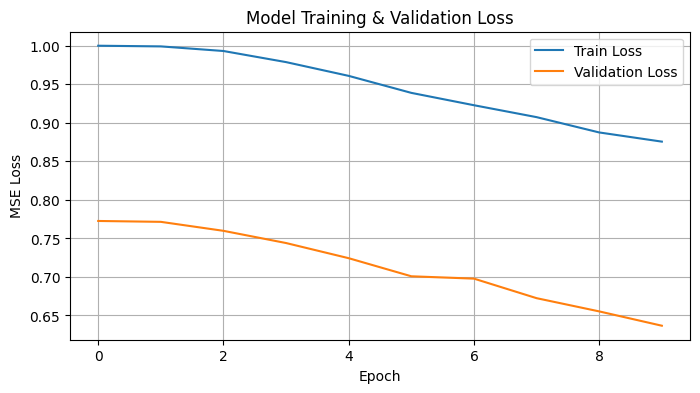

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Validation Loss")
plt.title("Model Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()


## Evaluation & Anomaly Detection
We evaluate the model on the Validation set (Unseen Normal) vs the `test` folder to compare their reconstruction errors.

In [9]:
def get_reconstruction_errors(loader):
    model.eval()
    errors = []
    with torch.no_grad():
        for batch_x, _ in loader:
            batch_x = batch_x.to(DEVICE)
            outputs = model(batch_x)
            
            # Calculate MSE per sequence
            # batch_x shape: (batch_size, seq_len, features)
            mse = torch.mean((outputs - batch_x) ** 2, dim=[1, 2])
            errors.extend(mse.cpu().numpy())
    return np.array(errors)

# Calculate errors
val_errors = get_reconstruction_errors(val_loader)
test_errors = get_reconstruction_errors(test_loader)

print(f"Validation (Normal) Errors: Mean = {np.mean(val_errors):.6f}, Std = {np.std(val_errors):.6f}")
print(f"Test Folder Errors: Mean = {np.mean(test_errors):.6f}, Std = {np.std(test_errors):.6f}")


Validation (Normal) Errors: Mean = 0.636672, Std = 2.736723
Test Folder Errors: Mean = 1.141442, Std = 3.675080


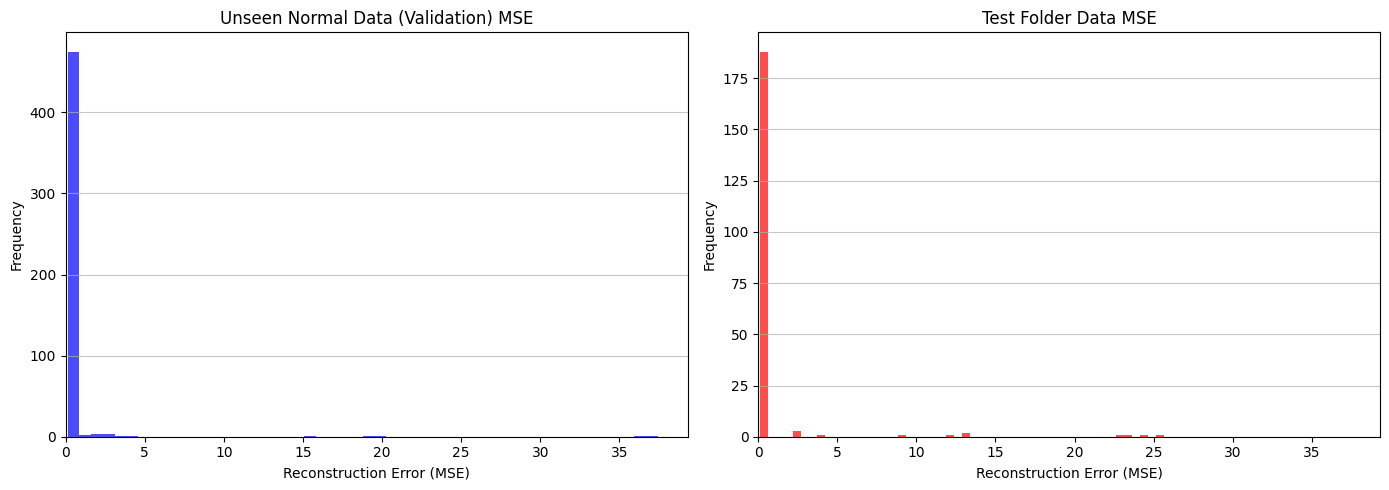

In [10]:
# Plot the distributions side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Unseen Normal Data
axes[0].hist(val_errors, bins=50, color='blue', alpha=0.7)
axes[0].set_title("Unseen Normal Data (Validation) MSE")
axes[0].set_xlabel("Reconstruction Error (MSE)")
axes[0].set_ylabel("Frequency")
axes[0].grid(axis='y', alpha=0.7)

# Plot 2: Test Folder Data
axes[1].hist(test_errors, bins=50, color='red', alpha=0.7)
axes[1].set_title("Test Folder Data MSE")
axes[1].set_xlabel("Reconstruction Error (MSE)")
axes[1].set_ylabel("Frequency")
axes[1].grid(axis='y', alpha=0.7)

# Make axes identical for easy comparison
max_error = max(np.max(val_errors), np.max(test_errors))
axes[0].set_xlim(0, max_error * 1.05)
axes[1].set_xlim(0, max_error * 1.05)

plt.tight_layout()
plt.show()


## ROC-AUC Evaluation
Assuming the `Validation` data represents pure 'Normal' (0) and the `test` folder represents 'Anomalous' (1), we can calculate the ROC-AUC score and plot the curve to see how well the model separates them.

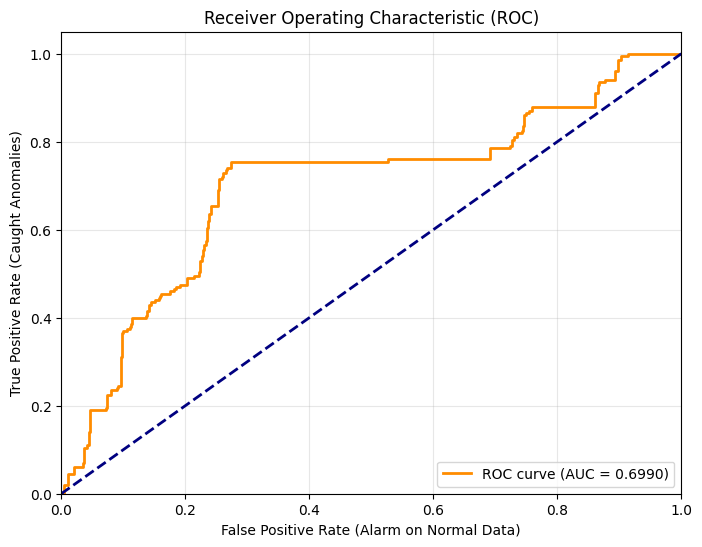

ROC-AUC Score: 0.6990
Poor separation. The test data looks very similar to the normal data.


In [11]:
from sklearn.metrics import roc_curve, auc

# Create synthetic true labels: 0 for normal (validation), 1 for anomalous (test)
y_true = np.concatenate([np.zeros(len(val_errors)), np.ones(len(test_errors))])

# The "scores" are the MSE errors (higher error = more likely to be an anomaly)
y_scores = np.concatenate([val_errors, test_errors])

# Calculate False Positive Rate, True Positive Rate, and Thresholds
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# Calculate the Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Alarm on Normal Data)')
plt.ylabel('True Positive Rate (Caught Anomalies)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")
if roc_auc > 0.9:
    print("Excellent separation! The model can easily distinguish between normal and test data.")
elif roc_auc > 0.7:
    print("Good separation. The model detects a difference, but there is some overlap.")
else:
    print("Poor separation. The test data looks very similar to the normal data.")
